# Content Creator Revenue Prediction using Random Forest Regressor & GridSearchCV

## 1.Problem Statement

- With the rapid growth of digital platforms such as YouTube, Instagram, and Twitch, content creators generate revenue based on multiple factors including audience engagement, content quality, consistency, and platform-specific monetization strategies. However, estimating a creator’s potential revenue is complex due to the interplay of these variables.

- Traditional estimation methods often rely on assumptions and lack data-driven accuracy. This project aims to develop a machine learning model that can predict a content creator’s monthly revenue based on various performance and engagement metrics, enabling better financial forecasting and strategic decision-making.

# 2.Objectives:

- To build a regression model using Random Forest Regressor to predict monthly revenue of content creators.
- To preprocess and handle both numerical and categorical features using appropriate encoding techniques.
- To apply GridSearchCV for hyperparameter tuning to improve model performance.
- To evaluate the model using regression metrics such as R² Score, Mean Absolute Error (MAE), and Mean Squared Error (MSE).
- To analyze the impact of different features such as engagement, consistency, and platform on revenue generation.
- To develop a complete machine learning solution covering data preparation, model training, tuning, and evaluation.

## 3.Import Libraries

In [2]:
import numpy as np 
import pandas as pd

## 4.Load Dataset

In [3]:
df = pd.read_csv("regressor_destroyer_dataset.csv")
df.head(7)

,Creator_Experience_Years,Videos_Per_Month,Avg_Watch_Time_Min,Content_Quality_Score,Niche_Competition,Thumbnail_ClickRate,Upload_Consistency,Audience_Retention,Ad_CPM,Platform,Content_Type,Audience_Region,Monthly_Revenue
0,9,16,6.373212,6,0.553046,14.177251,6,25.828178,2.861541,Instagram,Gaming,India,4150.435989
1,0,62,12.487305,8,0.375912,4.169434,7,34.876227,12.872190,YouTube,Education,India,5270.354480
2,11,48,24.800331,8,0.487942,2.778283,6,63.636273,8.607819,Twitch,Gaming,Europe,5745.827244
3,1,72,14.653501,1,0.390249,12.672890,4,33.240446,8.172716,YouTube,Education,US,5168.962760
4,7,52,21.333441,4,0.181407,1.351549,3,34.694878,3.509520,Instagram,Gaming,US,4382.980103
5,1,27,6.585433,8,0.432828,4.462016,8,60.320357,14.448499,YouTube,Gaming,Europe,5710.914010
6,7,53,11.377957,1,0.489106,16.949143,8,90.210758,6.526570,Twitch,Gaming,Europe,5140.724097


In [4]:
df["Engagement_Score"] = (
    df["Audience_Retention"] * df["Thumbnail_ClickRate"]
)

## 5.Check Missing Values & Handle

In [5]:
df.isnull().sum()

Creator_Experience_Years    0
Videos_Per_Month            0
Avg_Watch_Time_Min          0
Content_Quality_Score       0
Niche_Competition           0
Thumbnail_ClickRate         0
Upload_Consistency          0
Audience_Retention          0
Ad_CPM                      0
Platform                    0
Content_Type                0
Audience_Region             0
Monthly_Revenue             0
Engagement_Score            0
dtype: int64

## 6.Preprocessing

In [6]:
df = pd.get_dummies(df,columns=["Platform", "Content_Type", "Audience_Region"]) # One-hot encoder
df

,Creator_Experience_Years,Videos_Per_Month,Avg_Watch_Time_Min,Content_Quality_Score,Niche_Competition,Thumbnail_ClickRate,Upload_Consistency,Audience_Retention,Ad_CPM,Monthly_Revenue,Engagement_Score,Platform_Instagram,Platform_Twitch,Platform_YouTube,Content_Type_Education,Content_Type_Gaming,Content_Type_Vlog,Audience_Region_Europe,Audience_Region_India,Audience_Region_US
0,9,16,6.373212,6,0.553046,14.177251,6,25.828178,2.861541,4150.435989,366.172574,True,False,False,False,True,False,False,True,False
1,0,62,12.487305,8,0.375912,4.169434,7,34.876227,12.872190,5270.354480,145.414136,False,False,True,True,False,False,False,True,False
2,11,48,24.800331,8,0.487942,2.778283,6,63.636273,8.607819,5745.827244,176.799563,False,True,False,False,True,False,True,False,False
3,1,72,14.653501,1,0.390249,12.672890,4,33.240446,8.172716,5168.962760,421.252526,False,False,True,True,False,False,False,False,True
4,7,52,21.333441,4,0.181407,1.351549,3,34.694878,3.509520,4382.980103,46.891828,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,6,16,6.358257,7,0.485534,7.728788,1,42.999778,6.547986,4612.443551,332.336152,False,True,False,True,False,False,False,False,True
1596,7,40,8.470093,5,0.913938,9.197973,2,45.110759,11.643103,5421.048421,414.927545,True,False,False,True,False,False,True,False,False
1597,7,76,20.852807,8,0.613640,6.701169,7,35.514607,7.762251,5638.362636,237.989391,False,False,True,True,False,False,True,False,False
1598,11,67,14.382945,7,0.596987,4.642562,4,48.469323,10.785811,5628.003209,225.021826,True,False,False,False,False,True,True,False,False


## 7.Model Building

### i) Seperate Target & Feature

In [7]:
X = df.drop("Monthly_Revenue", axis=1)
y = df["Monthly_Revenue"]

### ii) Split The Dataset

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

### iii) Select Model

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

### iv) GridSearchCV

In [15]:
from sklearn.model_selection import GridSearchCV

# Step 1: Model
rf = RandomForestRegressor(random_state=42)

# Step 2: Hyperparameter Grid
param_grid = {
    'n_estimators': [200, 300, 400],      # number of trees
    'max_depth': [10, 15, 20, None],      # depth of trees
    'min_samples_split': [2, 5, 10],      # split condition
    'min_samples_leaf': [1, 2, 4],        # leaf size
    'max_features': ['sqrt', 'log2']      # features per split
}

# Step 3: GridSearchCV
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',        # for regression
    n_jobs=-1
)


### v) Train Model

In [16]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 15, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [200, 300, 400]},
             scoring='r2')

### vi) Get Best Model

In [17]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
0.8447602928312232


## 8.Predict

In [18]:
y_pred = grid.predict(X_test)
print(y_pred)

[5359.34000816 4799.93349636 3963.54989052 4448.57496075 5160.05663252
 4415.40772094 4617.23440428 4505.64412636 4353.35129351 4507.53670478
 4585.68146631 4950.90292461 5747.78555651 5926.01427259 5064.60846487
 4943.46062811 4184.9657877  5769.18514598 4722.46274605 5445.41267349
 4626.10206905 5037.9884973  4510.21002675 4723.75118858 4168.78871601
 4194.57231515 4174.0960819  6002.21228781 4696.88111692 5101.86664816
 5992.79960429 6205.86547008 4668.18838897 4024.97091743 5551.63884097
 4357.93372676 5546.07823527 5485.59832127 5002.67493475 5822.3445397
 3620.90100993 5046.6488434  4885.30472559 4882.42900704 4710.37774132
 4425.09523972 6101.49037854 5506.8072146  5261.02030115 3905.9937497
 5824.91279991 5208.66406409 5398.20770221 6039.46845922 4971.35275771
 4381.5325517  5390.7796203  5677.19631301 4868.93580279 4093.98829786
 4883.95239466 4308.26624951 4804.77466476 4329.94866349 4587.6223138
 5294.85077916 4540.56494553 4813.71925408 4896.9517093  4158.01556176
 4654.509

## 9.Evaluate

In [21]:
from sklearn.metrics import mean_absolute_error,r2_score
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean absolute error:",mae)
print("R2 score:",r2)

Mean absolute error: 242.48433939231032
R2 score: 0.8642058150026135


## 10. Graph : Actual Vs Predicted

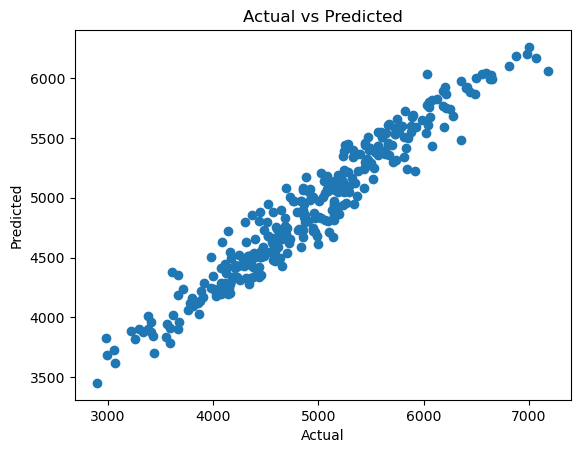

In [22]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()